In [1]:
import wntr
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
import os
import wntr.network.controls as controls
from wntr.network.controls import LinkStatus
import copy

dt = 1800
t_run = 24

inp = 'C-Town.inp'
wn = wntr.network.WaterNetworkModel(inp)
wn.options.time.report_timestep=dt    
wn.options.time.duration=t_run*3600
sim = wntr.sim.EpanetSimulator(wn)
results = sim.run_sim()

wntr_heads=results.node['head'].iloc[:-1,:]
wntr_flows=results.link['flowrate'].iloc[:-1,:]
J256_head=wntr_heads['J256']
pump2_flow=wntr_flows['P796']*1000
J238_head=wntr_heads['J238']
J287_head=wntr_heads['J287']
T3_head=wntr_heads['T3']

# (1) only static uncertainty

In [2]:
# 5 patterns
DMA_patterns = {
    'DMA1_pat': wn.get_pattern('DMA1_pat').multipliers,
    'DMA2_pat': wn.get_pattern('DMA2_pat').multipliers,
    'DMA3_pat': wn.get_pattern('DMA3_pat').multipliers,
    'DMA4_pat': wn.get_pattern('DMA4_pat').multipliers,
    'DMA5_pat': wn.get_pattern('DMA5_pat').multipliers,
}

num_runs = 100
seeds = range(num_runs)

# save results
noisy_results_pump2 = []
noisy_results_J256 = []
noisy_results_T3 = []
noisy_results_J287 = []
noisy_results_J238 = []

for seed in seeds:
    np.random.seed(seed)

    # add noise to each pattern
    for pat_name, original_multipliers in DMA_patterns.items():
        noise = np.random.normal(loc=0.0, scale=0.1, size=len(original_multipliers))
        noisy_multipliers = original_multipliers * (1 + noise)
        wn.get_pattern(pat_name).multipliers = noisy_multipliers.tolist()
    
    # run simulation
    sim = wntr.sim.EpanetSimulator(wn)
    results = sim.run_sim()

    # save results at selcted locations
    pump2 = results.link['flowrate'].iloc[:-1, :]['P796']*1000   # Pump2 flow
    T3_head = results.node['head'].iloc[:-1, :]['T3'] # J256 head
    J256_head = results.node['head'].iloc[:-1, :]['J256'] # J256 head
    J238_head = results.node['head'].iloc[:-1, :]['J238'] # J238 head
    J287_head = results.node['head'].iloc[:-1, :]['J287'] # J287 head

    noisy_results_pump2.append(pump2)
    noisy_results_T3.append(T3_head)
    noisy_results_J256.append(J256_head)
    noisy_results_J238.append(J238_head)
    noisy_results_J287.append(J287_head)


# (2) only operational uncertainty

In [3]:
# Create a WaterNetworkModel from an EPANET INP file
wn_base = wntr.network.WaterNetworkModel(inp)

tank_name = "T3"
pump_name = "PU4"

results_dict = {}
results_list = []

#  low_cond: 2~4, high_cond: 4~6
for low in np.arange(2.0, 3.0, 0.2):     # adjustable
    for high in np.arange(4.7, 5.9, 0.1): # adjustable
        if high <= low:   # avoid infeasible cases
            continue
        
        # clone the network
        wn = copy.deepcopy(wn_base)
        
        tank = wn.get_node(tank_name)
        pump = wn.get_link(pump_name)

        # remove the orginal control 7,8（if exist）
        try:
            wn.remove_control('control 7')
            wn.remove_control('control 8')
        except:
            pass

        # define action
        open_action  = controls.ControlAction(pump, "status", LinkStatus.Open)
        close_action = controls.ControlAction(pump, "status", LinkStatus.Closed)

        # define condition
        low_cond  = controls.ValueCondition(tank, "level", "<", low)
        high_cond = controls.ValueCondition(tank, "level", ">", high)

        # define control
        open_ctrl  = controls.Control(low_cond, open_action)
        close_ctrl = controls.Control(high_cond, close_action)

        # add control
        wn.add_control(f"open_PU4_if_T3_below_{low}", open_ctrl)
        wn.add_control(f"close_PU4_if_T3_above_{high}", close_ctrl)

        # run simulation
        sim = wntr.sim.EpanetSimulator(wn)  
        results = sim.run_sim()
        results_list.append(results)

        # save to dict
        results_dict[(low, high)] = results

# (3) plots

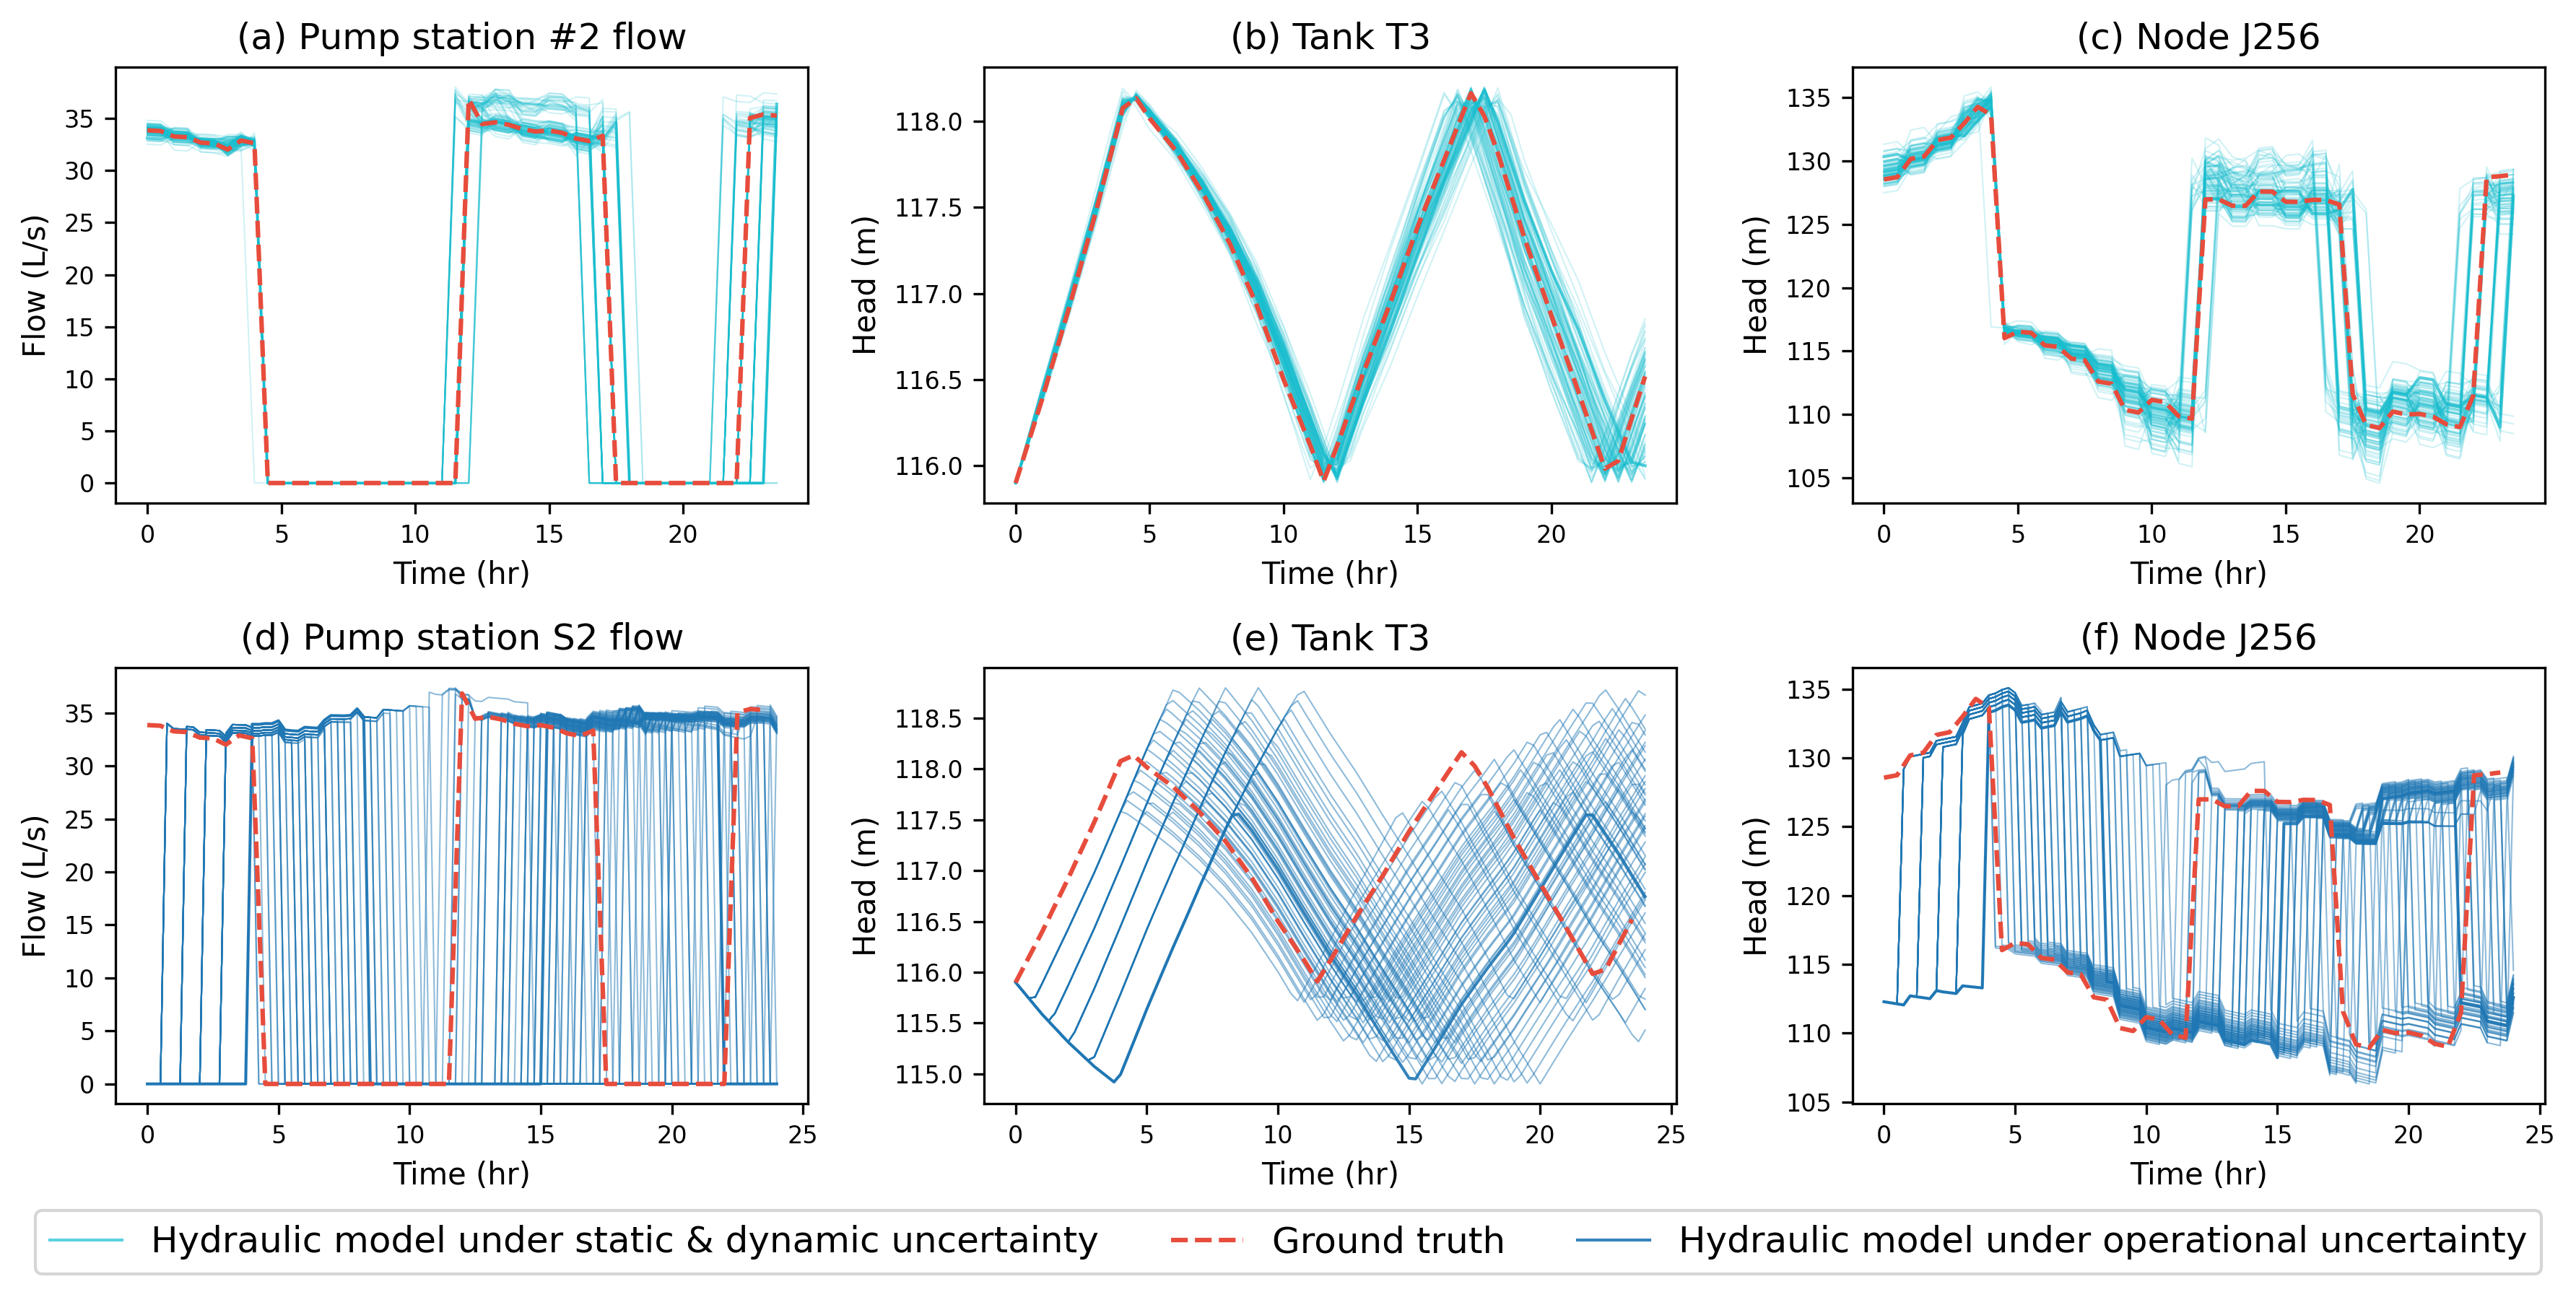

In [4]:
# ----- Color palette -----
static_color = '#17becf'   # blue for static & dynamic uncertainty
operational_color = '#1f77b4'
truth_color = '#e74c3c'    # red for ground truth

fig, axes = plt.subplots(2, 3, figsize=(12, 6), dpi=300)
axes = axes.flatten()

# =======================
# (a)–(d): Static & Dynamic Uncertainty
# =======================
data_list_1 = [
    (noisy_results_pump2, pump2_flow, 'Flow (L/s)', 'Pump station #2 flow'),
    (noisy_results_T3, T3_head, 'Head (m)', 'Tank T3'),
    (noisy_results_J256, J256_head, 'Head (m)', 'Node J256')
]

letters_1 = ['(a)', '(b)', '(c)']

for ax, (noisy_results, truth, ylabel, title), letter in zip(axes[:3], data_list_1, letters_1):
    for i, sim in enumerate(noisy_results):
        if i == 0:
            ax.plot(sim.index/3600, sim.values,
                    color=static_color, alpha=0.7, linewidth=1,
                    label='Hydraulic model under static & dynamic uncertainty')
        else:
            ax.plot(sim.index/3600, sim.values,
                    color=static_color, alpha=0.2, linewidth=0.5)

    ax.plot(truth.index/3600, truth.values,
            color=truth_color, linestyle='--', label='Ground truth')

    ax.set_xlabel('Time (hr)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{letter} {title}', fontsize=12, loc='center')
    ax.tick_params(labelsize=8)

# =======================
# (e)–(h): Operational Uncertainty
# =======================
data_list_2 = [
    ('flowrate', 'P796', pump2_flow, 'Flow (L/s)', 'Pump station S2 flow'),
    ('head', 'T3', T3_head, 'Head (m)', 'Tank T3'),
    ('head', 'J256', J256_head, 'Head (m)', 'Node J256')
]

letters_2 = ['(d)', '(e)', '(f)']

for ax, (var_type, element_name, truth, ylabel, title), letter in zip(axes[3:], data_list_2, letters_2):
    for i, res in enumerate(results_list):
        if var_type == 'flowrate':
            series = res.link['flowrate'].loc[:, element_name] * 1000  # convert to L/s
        elif var_type == 'head':
            series = res.node['head'].loc[:, element_name]  # m
        else:
            continue

        if i == 0:
            ax.plot(series.index / 3600, series.values,
                    color=operational_color, alpha=0.9, linewidth=1, label='Hydraulic model under operational uncertainty')
        else:
            ax.plot(series.index / 3600, series.values,
                    color=operational_color, alpha=0.5, linewidth=0.5)

    ax.plot(truth.index / 3600, truth.values,
            color=truth_color, linestyle='--', label='Ground truth')

    ax.set_xlabel('Time (hr)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{letter} {title}', fontsize=12, loc='center')
    ax.tick_params(labelsize=8)

# =======================
# Unified Legend & Layout
# =======================
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for hi, li in zip(h, l):
        if li not in labels: 
            handles.append(hi)
            labels.append(li)
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=12, frameon=True)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()
